In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import os
from PIL import Image
from tqdm.notebook import tqdm
import torch
from topodataset import TopoDataSet
import utils


In [2]:
os.getcwd()

'D:\\topochip-flow-matching\\Topochip-flow-matching'

In [3]:
# load the data:
# DATASETS/DATALOADER
bs=8
num_workers=0
downsampling_factor=1
limit_num_data=np.inf
crop_size=300
threshold_input=True


dataset = TopoDataSet(
    dir='data/',
    downsampling_factor=downsampling_factor,
    limit_num_data=limit_num_data,
    crop_size=crop_size,
    threshold_input=threshold_input,
    return_filename=True
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=bs,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)


0it [00:00, ?it/s]
0it [00:00, ?it/s]
100%|██████████| 682/682 [00:00<00:00, 335780.65it/s]
0it [00:00, ?it/s]
100%|██████████| 696/696 [00:00<00:00, 656893.70it/s]
0it [00:00, ?it/s]
100%|██████████| 843/843 [00:00<00:00, 336358.28it/s]
0it [00:00, ?it/s]
100%|██████████| 712/712 [00:00<00:00, 385533.75it/s]
0it [00:00, ?it/s]
100%|██████████| 856/856 [00:00<00:00, 855042.68it/s]
0it [00:00, ?it/s]
100%|██████████| 635/635 [00:00<00:00, 184828.80it/s]
0it [00:00, ?it/s]
100%|██████████| 534/534 [00:00<00:00, 197092.43it/s]
0it [00:00, ?it/s]
100%|██████████| 427/427 [00:00<00:00, 426217.95it/s]
0it [00:00, ?it/s]
100%|██████████| 613/613 [00:00<00:00, 327989.33it/s]
0it [00:00, ?it/s]
100%|██████████| 608/608 [00:00<00:00, 230844.29it/s]
0it [00:00, ?it/s]
100%|██████████| 699/699 [00:00<00:00, 345204.11it/s]
0it [00:00, ?it/s]
100%|██████████| 717/717 [00:00<00:00, 324764.14it/s]
0it [00:00, ?it/s]
100%|██████████| 656/656 [00:00<00:00, 655266.35it/s]

dataset contains 8678 images


In [4]:
source = 'real'
stain_names = ['background', 'YAP', 'Actin', 'DAPI']
save_folder = 'real_images_29-4-25_insert_preproc'


In [5]:
counter = 0

for i, batch in tqdm(enumerate(dataloader), total=len(dataloader)):
    for (img, bg, fname) in zip(*batch):
        obj_num = fname.split('Nr')[1].split('.png')[0]
        chip = fname.split('/')[1].split('\\')[0]
        save_fold_this = os.path.join(save_folder, chip +f'_{source}')
        if not os.path.exists(save_fold_this):
            os.makedirs(save_fold_this)
        all_channels = torch.cat([bg, img], dim=0)
        # print(all_channels.shape)
        # to_plot = utils.plot_topo_cells_one_im(all_channels.permute(1,2,0).numpy(), bg_norm=0.4)
        # plt.imshow(to_plot)
        # plt.show()
        # normalize to [0,1] instead of [-1,1]:
        all_channels = (all_channels + 1) / 2
        assert (0 <= all_channels.min()) and (all_channels.max() <= 1)
        for c, channel in enumerate(all_channels):
            assert channel.shape == (crop_size, crop_size)
            try:
                im_channel = Image.fromarray((channel.numpy() * 255).astype(np.uint8))
                fname_save = f'obj{obj_num}_stain{stain_names[c]}_{source}.tiff'
                # print(fname, save_fold_this, fname_save)
                im_channel.save(os.path.join(save_fold_this, fname_save))
                counter += 1
            except Exception as e:
                print(f'failed to convert {fname}')
                print(e)




  0%|          | 0/1084 [00:00<?, ?it/s]

D:\topochip-flow-matching\Topochip-flow-matching\utils.py:259: RuntimeWarning: All-NaN slice encountered
  assert (np.nanmin(np.where(arr > (0+(1e-6)), arr_norm, np.nan), axis=(0,1)) >= (0-1e-6)).all() or (arr==0).all((0,1)).any(), 'normalization did not give expected results: lowest < 0'


In [6]:
fname

'data/Chip_2065_1\\QualityCheckPassed\\reconstruction_NucleiNr0035.png.mat'

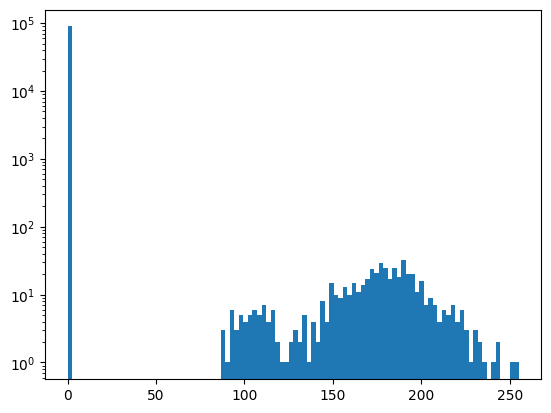

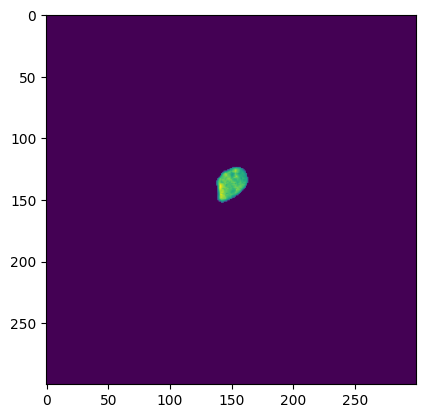

In [9]:
test = Image.open(
    os.path.join(save_folder, 'Chip_1130_1_real/obj0041_stainDAPI_real.tiff')
    )
plt.hist(np.array(test).reshape(-1), bins=100)
plt.yscale('log')
plt.show()

plt.imshow(np.array(test))
plt.show()

In [39]:
# loading/saving parameters:
# source = 'real'
# stain_names = ['background', 'DAPI', 'Actin', 'YAP']
# save_folder = 'real_images_5-3-25_fixed'
# chips = [
#     'Chip_1130_1', 'Chip_1130_2', 'Chip_1330_1', 
#     'Chip_1462_1', 'Chip_1476_1', 'Chip_1689_1', 'Chip_1710_1', 'Chip_1710_2',
#         'Chip_1913_1','Chip_2065_1','Chip_2088_1','Chip_2113_1','Chip_2113_2',
# ]


# crop = 300 # make a (crop x crop) image from the center
# max_imgs_per_chip = 1000

# # where to load the data from -- part that is the same for all chips
# prefix_load = os.path.join('data')
# suffix_load = 'QualityCheckPassed'


# # do the loading and converting:
# load_folders = [os.path.join(prefix_load, c, suffix_load) for c in chips]
# save_folders = [os.path.join(save_folder, c + f'_{source}') for c in chips]

# for load_fold in load_folders:
#     assert os.path.exists(load_fold), f'error: load folder {load_fold} not found!'

# for load_fold, save_fold in tqdm(zip(load_folders, save_folders), total=len(load_folders)):
#     get_tiffs_from_mat(stain_names, save_fold, load_fold, crop, max_imgs_per_chip)
    
# print('done!')



# def get_tiffs_from_mat(stain_names, save_folder, load_folder, crop=300, max_imgs=None):
#     if not os.path.exists(load_folder):
#         raise FileNotFoundError('load_folder not found!')
#     if not os.path.exists(save_folder):
#         os.makedirs(save_folder)
    
#     if max_imgs is None:
#         max_imgs = np.inf
    
#     counter = 0
    
#     # load the data from all subfolders in load_folder and convert to tiff:
#     for path, subdirs, files in os.walk(load_folder):
#         if counter >= max_imgs:
#             break
#         for name in files:
#             if counter >= max_imgs:
#                 break
#             if name.endswith('.mat'):
#                 try:
#                     obj_num = name.split('Nr')[1].split('.png')[0]
#                     mat = loadmat(os.path.join(path, name))
#                     im = mat['I'].astype(float)
#                     for c in range(im.shape[-1]):
#                         channel = im[..., c]
#                         channel = normalize_channel(channel)
#                         channel = (channel * 255).astype(np.uint8)
#                         # crop:
#                         h, w = channel.shape[:2]
#                         channel = channel[h//2-crop//2:h//2+crop//2, w//2-crop//2:w//2+crop//2]
#                         im_channel = Image.fromarray(channel)
#     #                     print(im_channel.getextrema())
#                         fname_save = f'obj{obj_num}_stain{stain_names[c]}_{source}.tiff'
#                         im_channel.save(os.path.join(save_folder, fname_save))
#                     counter += 1
#                 except Exception as e:
#                     print(f'failed to convert {os.path.join(path, name)}')
#                     print(e)
#         print('saved at',os.path.join(save_folder,))
                
#     return 

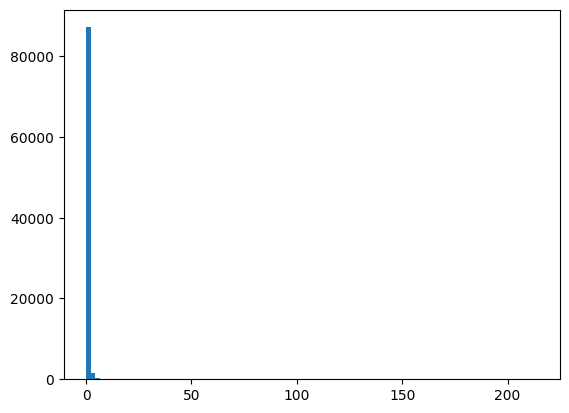

In [21]:
plt.hist(np.array(test).reshape(-1), bins=100)
plt.show()

In [22]:
np.max(test)

214

In [24]:
test2 = Image.open('../cellprofiler validation/real_images_subsampled_small/Chip_1130_1_real/obj0008_stainDAPI_real.tiff')

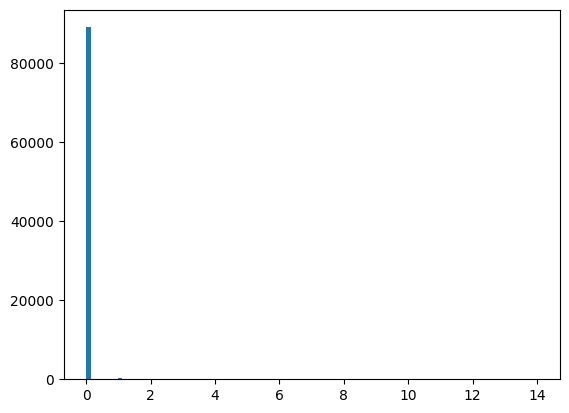

In [25]:
plt.hist(np.array(test2).reshape(-1), bins=100)
plt.show()

In [26]:
np.max(test2)

14

In [32]:
test3 = loadmat('data/Chip_1130_1/QualityCheckPassed/reconstruction_NucleiNr0002.png.mat')['I']

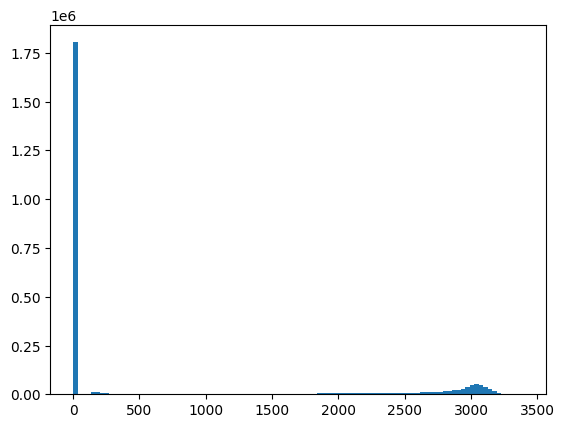

In [33]:
plt.hist(np.array(test3).reshape(-1), bins=100)
plt.show()

In [34]:
np.max(test3)

3399.0

In [9]:
test4 = Image.open('real_images_27-2-25_fixed/Chip_1130_1_real/obj0001_stainActin_real.tiff')

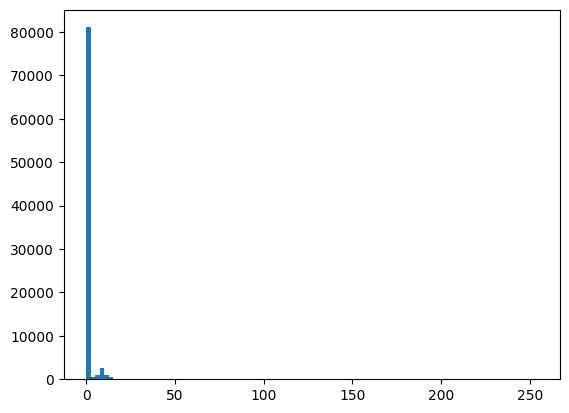

In [11]:
plt.hist(np.array(test4).reshape(-1), bins=100)
plt.show()

In [14]:
np.max(test4)

254

In [ ]:
# # archive functions:



# def normalize_channel(image_channel, ignore_zeros=True, do_simple_normalization=False):
#     arr = image_channel
#     if ignore_zeros:
#         mask = arr != 0
#         if mask.any(): # if we have any nonzero entries
#             low = arr[mask].min()
#         else:
#             low = 0.
#     else:
#         low = arr[...,i].min()

#     arr = np.maximum(arr - low, 0)  # keep zeros at zero
#     arr = arr / (arr.max() + 1e-6) # avoid division by zero error
#     # normalize to [0,1]
#     return arr
        
    

# def get_tiffs_from_mat(stain_names, save_folder, load_folder, crop=300, max_imgs=None):
#     if not os.path.exists(load_folder):
#         raise FileNotFoundError('load_folder not found!')
#     if not os.path.exists(save_folder):
#         os.makedirs(save_folder)
    
#     if max_imgs is None:
#         max_imgs = np.inf
    
#     counter = 0
    
#     # load the data from all subfolders in load_folder and convert to tiff:
#     for path, subdirs, files in os.walk(load_folder):
#         if counter >= max_imgs:
#             break
#         for name in files:
#             if counter >= max_imgs:
#                 break
#             if name.endswith('.mat'):
#                 try:
#                     obj_num = name.split('Nr')[1].split('.png')[0]
#                     mat = loadmat(os.path.join(path, name))
#                     im = mat['I'].astype(float)
#                     for c in range(im.shape[-1]):
#                         channel = im[..., c]
#                         channel = normalize_channel(channel)
#                         channel = (channel * 255).astype(np.uint8)
#                         # crop:
#                         h, w = channel.shape[:2]
#                         channel = channel[h//2-crop//2:h//2+crop//2, w//2-crop//2:w//2+crop//2]
#                         im_channel = Image.fromarray(channel)
#     #                     print(im_channel.getextrema())
#                         fname_save = f'obj{obj_num}_stain{stain_names[c]}_{source}.tiff'
#                         im_channel.save(os.path.join(save_folder, fname_save))
#                     counter += 1
#                 except Exception as e:
#                     print(f'failed to convert {os.path.join(path, name)}')
#                     print(e)
#         print('saved at',os.path.join(save_folder,))
                
#     return 

